# Bloque 0 — Auditoría de Calidad de Datos

**Prueba Técnica · Data Analyst · Cadena de Retail Multiformato · Centroamérica**

Antes de cualquier análisis exploratorio o modelo, auditamos los 6 datasets para entender su estado real. El proceso sigue una progresión natural:

1. **Carga inicial sin suposiciones** — descubrimos qué hay en cada archivo
2. **Corrección de tipos** — ajustamos lo que pandas infirió incorrectamente
3. **Auditoría por dimensión** — 8 chequeos de calidad con evidencia y decisión

> *Este notebook es un registro de exploración, no un pipeline de producción. Las decisiones documentadas aquí guían todos los bloques siguientes.*

**Dimensiones auditadas:**
1. Completitud
2. Consistencia
3. Unicidad
4. Validez
5. Integridad Referencial
6. Frescura
7. Integridad Temporal
8. Integridad del A/B Test


## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_PATH = './Datasets/'
os.makedirs('./bloque3_visualizaciones', exist_ok=True)

print('✅ Setup OK')

✅ Setup OK


## 1. Carga Inicial — Sin Suposiciones

Cargamos cada archivo con `pd.read_csv()` básico, sin indicar tipos ni fechas. El objetivo es ver exactamente lo que pandas infiere y detectar qué necesitamos corregir antes de analizar.


### 1.1 `transactions.csv`

In [2]:
transactions = pd.read_csv(DATA_PATH + 'transactions.csv')
print(f'Shape: {transactions.shape}')
transactions.info()

Shape: (174880, 8)


<class 'pandas.DataFrame'>
RangeIndex: 174880 entries, 0 to 174879
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    174880 non-null  str    
 1   customer_id       70248 non-null   str    
 2   transaction_date  174880 non-null  str    
 3   store_id          174880 non-null  str    
 4   total_amount      174880 non-null  float64
 5   payment_method    174880 non-null  str    
 6   loyalty_card      174880 non-null  bool   
 7   status            174880 non-null  str    
dtypes: bool(1), float64(1), str(6)
memory usage: 9.5 MB


In [3]:
transactions.head(3)

,transaction_id,customer_id,transaction_date,store_id,total_amount,payment_method,loyalty_card,status
0,TX_00000001,NaN,2024-01-01,TIENDA_001,120.98,CARD,False,COMPLETED
1,TX_00000002,NaN,2024-01-01,TIENDA_001,47.09,CASH,False,COMPLETED
2,TX_00000003,NaN,2024-01-01,TIENDA_001,195.55,CASH,False,COMPLETED


In [4]:
transactions.describe(include='all')

,transaction_id,customer_id,transaction_date,store_id,total_amount,payment_method,loyalty_card,status
count,174880,70248,174880,174880,"174,880.00",174880,174880,174880
unique,174880,3000,547,40,NaN,3,2,2
top,TX_00000001,CUST_02629,2024-12-22,TIENDA_008,NaN,CARD,False,COMPLETED
freq,1,45,475,8555,NaN,87525,104632,171327
mean,NaN,NaN,NaN,NaN,278.59,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,334.28,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,71.10,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,157.19,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,357.27,NaN,NaN,NaN


**Observaciones iniciales:**
- `transaction_date` fue cargada como `object` (texto) → necesita conversión a `datetime`
- `transaction_id`, `customer_id`, `store_id` son numéricos según pandas, pero son identificadores → deben ser `string`
- `loyalty_card` aparece como `bool` → correcto
- `total_amount` es `float64` → correcto para moneda


### 1.2 `transaction_items.csv`

In [5]:
transaction_items = pd.read_csv(DATA_PATH + 'transaction_items.csv')
print(f'Shape: {transaction_items.shape}')
transaction_items.info()

Shape: (542015, 6)
<class 'pandas.DataFrame'>
RangeIndex: 542015 entries, 0 to 542014
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaction_item_id  542015 non-null  str    
 1   transaction_id       542015 non-null  str    
 2   item_id              542015 non-null  str    
 3   quantity             542015 non-null  int64  
 4   unit_price           542015 non-null  float64
 5   was_on_promo         542015 non-null  bool   
dtypes: bool(1), float64(1), int64(1), str(3)
memory usage: 21.2 MB


In [6]:
transaction_items.head(3)

,transaction_item_id,transaction_id,item_id,quantity,unit_price,was_on_promo
0,TXI_000000001,TX_00000001,ITEM_194,1,10.09,False
1,TXI_000000002,TX_00000001,ITEM_060,2,19.08,False
2,TXI_000000003,TX_00000001,ITEM_175,2,22.63,False


In [7]:
transaction_items[['quantity', 'unit_price']].describe()

,quantity,unit_price
count,"542,015.00","542,015.00"
mean,1.60,56.20
std,0.86,94.19
min,1.00,0.00
25%,1.00,10.19
50%,1.00,19.82
75%,2.00,59.75
max,4.00,524.95


**Observaciones iniciales:**
- `transaction_item_id`, `transaction_id`, `item_id` → misma situación: son IDs, no números
- `unit_price` y `quantity` son numéricos → correcto
- `was_on_promo` es `bool` → correcto


### 1.3 `stores.csv`

In [8]:
stores = pd.read_csv(DATA_PATH + 'stores.csv')
print(f'Shape: {stores.shape}')
stores.info()

Shape: (40, 8)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   store_id      40 non-null     str  
 1   store_name    40 non-null     str  
 2   country       40 non-null     str  
 3   city          40 non-null     str  
 4   format        40 non-null     str  
 5   size_sqm      40 non-null     int64
 6   opening_date  40 non-null     str  
 7   region        40 non-null     str  
dtypes: int64(1), str(7)
memory usage: 2.6 KB


In [9]:
stores.head()

,store_id,store_name,country,city,format,size_sqm,opening_date,region
0,TIENDA_001,Tienda San José 1,CR,San José,HIPERMERCADO,7037,2023-11-24,Sur
1,TIENDA_002,Tienda Guatemala City 2,GT,Guatemala City,HIPERMERCADO,7016,2023-05-06,Capital
2,TIENDA_003,Tienda La Ceiba 3,HN,La Ceiba,HIPERMERCADO,4356,2023-12-13,Occidente
3,TIENDA_004,Tienda San Salvador 4,SV,San Salvador,HIPERMERCADO,4383,2023-08-05,Norte
4,TIENDA_005,Tienda Masaya 5,NI,Masaya,HIPERMERCADO,4108,2023-04-30,Occidente


In [10]:
print('Países:'); print(stores['country'].value_counts())
print()
print('Formatos:'); print(stores['format'].value_counts())
print()
stores[['size_sqm']].describe()

Países:
country
CR    8
GT    8
HN    8
SV    8
NI    8
Name: count, dtype: int64

Formatos:
format
SUPERMERCADO    15
DESCUENTO       12
HIPERMERCADO     8
EXPRESS          5
Name: count, dtype: int64



,size_sqm
count,40.00
mean,"2,429.57"
std,"1,851.24"
min,257.00
25%,"1,064.75"
50%,"1,694.50"
75%,"3,243.00"
max,"7,037.00"


**Observaciones iniciales:**
- `opening_date` es `object` → necesita conversión a `datetime`
- Columnas categóricas lucen limpias (sin valores extraños)


### 1.4 `products.csv`

In [11]:
products = pd.read_csv(DATA_PATH + 'products.csv')
print(f'Shape: {products.shape}')
products.info()

Shape: (200, 7)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   item_id     200 non-null    str    
 1   item_name   200 non-null    str    
 2   brand       200 non-null    str    
 3   vendor_id   200 non-null    str    
 4   category    200 non-null    str    
 5   department  200 non-null    str    
 6   cost        200 non-null    float64
dtypes: float64(1), str(6)
memory usage: 11.1 KB


In [12]:
products.head(3)

,item_id,item_name,brand,vendor_id,category,department,cost
0,ITEM_001,Juguetes Producto 1,Marca B,VND_016,Juguetes,Dep JUG,25.83
1,ITEM_002,Hogar Producto 2,Marca C,VND_006,Hogar,Dep HOG,75.27
2,ITEM_003,Hogar Producto 3,Marca D,VND_026,Hogar,Dep HOG,62.65


In [13]:
print('Categorías:'); print(products['category'].value_counts())
print()
products[['cost']].describe()

Categorías:
category
Alimentos           43
Hogar               40
Bebidas             23
Cuidado Personal    21
Ropa                21
Electrónica         20
Juguetes            18
Limpieza            14
Name: count, dtype: int64



,cost
count,200.00
mean,34.87
std,59.04
min,0.68
25%,6.52
50%,12.14
75%,37.82
max,343.35


**Observaciones iniciales:**
- Todos los tipos se ven razonables
- `item_id`, `vendor_id` son strings → bien
- `cost` es float → correcto para precio de costo


### 1.5 `vendors.csv`

In [14]:
vendors = pd.read_csv(DATA_PATH + 'vendors.csv')
print(f'Shape: {vendors.shape}')
vendors.info()

Shape: (30, 5)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   vendor_id          30 non-null     str  
 1   vendor_name        30 non-null     str  
 2   country            30 non-null     str  
 3   tier               30 non-null     str  
 4   is_shared_catalog  30 non-null     bool 
dtypes: bool(1), str(4)
memory usage: 1.1 KB


In [15]:
vendors.head()

,vendor_id,vendor_name,country,tier,is_shared_catalog
0,VND_001,Proveedor A,HN,A,False
1,VND_002,Proveedor B,US,A,True
2,VND_003,Proveedor C,SV,A,True
3,VND_004,Proveedor D,US,A,True
4,VND_005,Proveedor E,MX,A,True


In [16]:
print('Tiers:'); print(vendors['tier'].value_counts())
print()
print('is_shared_catalog:'); print(vendors['is_shared_catalog'].value_counts())

Tiers:
tier
A    10
B    10
C    10
Name: count, dtype: int64

is_shared_catalog:
is_shared_catalog
True     19
False    11
Name: count, dtype: int64


### 1.6 `store_promotions.csv`

In [17]:
store_promotions = pd.read_csv(DATA_PATH + 'store_promotions.csv')
print(f'Shape: {store_promotions.shape}')
store_promotions.info()

Shape: (42, 6)
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   store_id    42 non-null     str  
 1   promo_name  42 non-null     str  
 2   variant     42 non-null     str  
 3   start_date  42 non-null     str  
 4   end_date    42 non-null     str  
 5   promo_type  42 non-null     str  
dtypes: str(6)
memory usage: 2.1 KB


In [18]:
store_promotions.head(10)

,store_id,promo_name,variant,start_date,end_date,promo_type
0,TIENDA_008,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
1,TIENDA_037,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
2,TIENDA_001,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
3,TIENDA_011,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
4,TIENDA_009,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
5,TIENDA_018,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
6,TIENDA_033,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
7,TIENDA_035,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
8,TIENDA_014,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION
9,TIENDA_007,Exhibicion_Q3_2024,CONTROL,2024-09-01,2024-10-12,EXHIBICION


In [19]:
print('Variants:'); print(store_promotions['variant'].value_counts())
print()
print('Promo types:'); print(store_promotions['promo_type'].value_counts())
print()
print('Experimentos:'); print(store_promotions['promo_name'].value_counts())

Variants:
variant
TREATMENT    22
CONTROL      20
Name: count, dtype: int64

Promo types:
promo_type
EXHIBICION    42
Name: count, dtype: int64

Experimentos:
promo_name
Exhibicion_Q3_2024    42
Name: count, dtype: int64


**Observaciones iniciales:**
- `start_date` y `end_date` son `object` → necesitan conversión a `datetime`
- Dataset pequeño (42 filas) — contiene el diseño del experimento A/B


---
## 2. Corrección de Tipos

Basándonos en la exploración anterior, convertimos explícitamente los tipos que pandas infirió incorrectamente.

**Criterios:**
- **Fechas** (`object` → `datetime64`): necesarias para cálculos de rango, gaps y filtros temporales
- **IDs como enteros** (`int64` → `string`): los IDs no tienen operaciones aritméticas; tratarlos como texto evita comparaciones numéricas accidentales y asegura consistencia en los merges


In [20]:
# ── transactions ────────────────────────────────────────────────────────────
# transaction_date viene como "YYYY-MM-DD" → datetime
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# Los IDs son identificadores, no cantidades → string
transactions['transaction_id'] = transactions['transaction_id'].astype('string')
transactions['customer_id']    = transactions['customer_id'].astype('string')
transactions['store_id']       = transactions['store_id'].astype('string')

print('transactions — tipos corregidos:')
print(transactions[['transaction_id','transaction_date','customer_id','store_id']].dtypes)

transactions — tipos corregidos:
transaction_id              string
transaction_date    datetime64[us]
customer_id                 string
store_id                    string
dtype: object


In [21]:
# ── transaction_items ───────────────────────────────────────────────────────
transaction_items['transaction_item_id'] = transaction_items['transaction_item_id'].astype('string')
transaction_items['transaction_id']      = transaction_items['transaction_id'].astype('string')
transaction_items['item_id']             = transaction_items['item_id'].astype('string')

print('transaction_items — tipos corregidos:')
print(transaction_items[['transaction_item_id','transaction_id','item_id']].dtypes)

transaction_items — tipos corregidos:
transaction_item_id    string
transaction_id         string
item_id                string
dtype: object


In [22]:
# ── stores ──────────────────────────────────────────────────────────────────
# opening_date es fundamental para la auditoría de integridad temporal
stores['opening_date'] = pd.to_datetime(stores['opening_date'])

print('stores — opening_date:')
print(stores[['store_id','store_name','opening_date']].head())

stores — opening_date:
     store_id               store_name opening_date
0  TIENDA_001        Tienda San José 1   2023-11-24
1  TIENDA_002  Tienda Guatemala City 2   2023-05-06
2  TIENDA_003        Tienda La Ceiba 3   2023-12-13
3  TIENDA_004    Tienda San Salvador 4   2023-08-05
4  TIENDA_005          Tienda Masaya 5   2023-04-30


In [23]:
# ── store_promotions ─────────────────────────────────────────────────────────
store_promotions['start_date'] = pd.to_datetime(store_promotions['start_date'])
store_promotions['end_date']   = pd.to_datetime(store_promotions['end_date'])

print('store_promotions — fechas:')
print(store_promotions[['promo_name','variant','start_date','end_date']].head())

store_promotions — fechas:
           promo_name  variant start_date   end_date
0  Exhibicion_Q3_2024  CONTROL 2024-09-01 2024-10-12
1  Exhibicion_Q3_2024  CONTROL 2024-09-01 2024-10-12
2  Exhibicion_Q3_2024  CONTROL 2024-09-01 2024-10-12
3  Exhibicion_Q3_2024  CONTROL 2024-09-01 2024-10-12
4  Exhibicion_Q3_2024  CONTROL 2024-09-01 2024-10-12


In [24]:
# ── Verificación global ──────────────────────────────────────────────────────
print('=== Tipos finales por dataset ===')
for name, df in [('transactions', transactions), ('transaction_items', transaction_items),
                 ('stores', stores), ('store_promotions', store_promotions)]:
    date_cols = df.select_dtypes(include='datetime').columns.tolist()
    str_cols  = df.select_dtypes(include='string').columns.tolist()
    print(f'{name}: datetime={date_cols}, string_ids={str_cols}')
print('\n✅ Correcciones aplicadas. Listos para auditar.')

=== Tipos finales por dataset ===
transactions: datetime=['transaction_date'], string_ids=['transaction_id', 'customer_id', 'store_id', 'payment_method', 'status']
transaction_items: datetime=[], string_ids=['transaction_item_id', 'transaction_id', 'item_id']
stores: datetime=['opening_date'], string_ids=['store_id', 'store_name', 'country', 'city', 'format', 'region']
store_promotions: datetime=['start_date', 'end_date'], string_ids=['store_id', 'promo_name', 'variant', 'promo_type']

✅ Correcciones aplicadas. Listos para auditar.


---
## 3. Dimensión 1: Completitud

> **Pregunta:** ¿Qué porcentaje de transacciones no tiene `customer_id`? ¿Es consistente con `loyalty_card = FALSE`?


In [25]:
total_tx = len(transactions)

sin_customer   = transactions['customer_id'].isna() | (transactions['customer_id'] == '')
n_sin_customer = sin_customer.sum()
pct_sin_customer = n_sin_customer / total_tx * 100

print(f'Total transacciones:  {total_tx:>10,}')
print(f'Sin customer_id:      {n_sin_customer:>10,}  ({pct_sin_customer:.2f}%)')
print(f'Con customer_id:      {total_tx - n_sin_customer:>10,}  ({100 - pct_sin_customer:.2f}%)')

Total transacciones:     174,880
Sin customer_id:         104,632  (59.83%)
Con customer_id:          70,248  (40.17%)


In [26]:
# Hipótesis: customer_id nulo ↔ loyalty_card = False
loyalty_true   = transactions['loyalty_card'] == True
loyalty_false  = transactions['loyalty_card'] == False
tiene_customer = ~sin_customer

# Caso A: sin customer_id PERO loyalty_card=True  → INCONSISTENTE
caso_a = (sin_customer & loyalty_true).sum()

# Caso B: con customer_id PERO loyalty_card=False → INCONSISTENTE
caso_b = (tiene_customer & loyalty_false).sum()

print('=== Consistencia customer_id ↔ loyalty_card ===')
print(f'loyalty_card=True,  sin customer_id  (caso A): {caso_a:>8,}  ← INCONSISTENTE')
print(f'loyalty_card=False, con customer_id  (caso B): {caso_b:>8,}  ← INCONSISTENTE')
print()

cross = pd.crosstab(
    sin_customer.map({True: 'customer_id=NULL', False: 'customer_id=SET'}),
    transactions['loyalty_card'].map({True: 'loyalty=TRUE', False: 'loyalty=FALSE'})
)
display(cross)

if caso_a == 0 and caso_b == 0:
    print('\n✅ HALLAZGO: customer_id y loyalty_card son 100% consistentes.')
else:
    print('\n⚠️  HALLAZGO: Existen inconsistencias entre customer_id y loyalty_card.')

=== Consistencia customer_id ↔ loyalty_card ===
loyalty_card=True,  sin customer_id  (caso A):        0  ← INCONSISTENTE
loyalty_card=False, con customer_id  (caso B):        0  ← INCONSISTENTE



loyalty_card,loyalty=FALSE,loyalty=TRUE
customer_id,,
customer_id=NULL,104632,0
customer_id=SET,0,70248



✅ HALLAZGO: customer_id y loyalty_card son 100% consistentes.


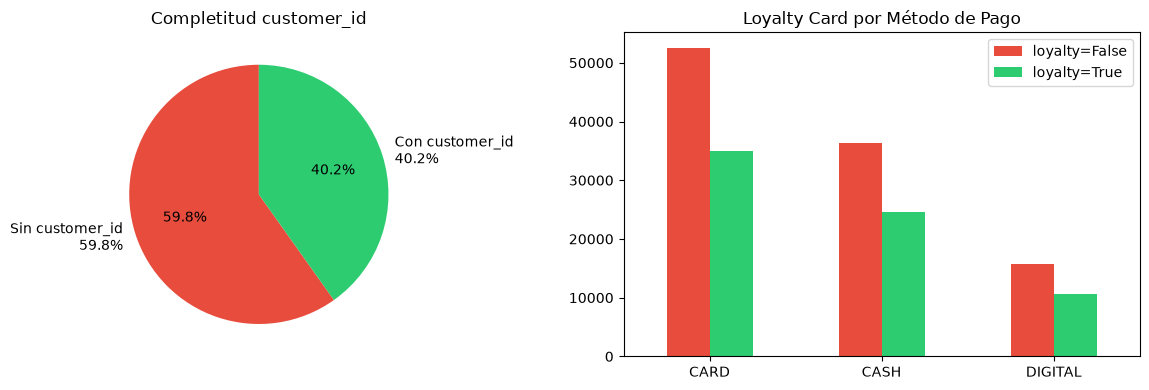

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [n_sin_customer, total_tx - n_sin_customer],
    labels=[f'Sin customer_id\n{pct_sin_customer:.1f}%', f'Con customer_id\n{100-pct_sin_customer:.1f}%'],
    colors=['#e74c3c', '#2ecc71'],
    startangle=90, autopct='%1.1f%%'
)
axes[0].set_title('Completitud customer_id')

lc_pm = transactions.groupby(['payment_method', 'loyalty_card']).size().unstack(fill_value=0)
lc_pm.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Loyalty Card por Método de Pago')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['loyalty=False', 'loyalty=True'])

plt.tight_layout()
plt.savefig('./bloque3_visualizaciones/b0_completitud.png', dpi=150, bbox_inches='tight')
plt.show()

**📋 DECISIÓN — Completitud:**
- Transacciones sin `customer_id` = clientes anónimos (sin tarjeta de lealtad) → **IGNORAR** (comportamiento esperado del negocio)
- Si existen inconsistencias (caso A o B) → **EXCLUIR** del análisis de cohortes de lealtad


---
## 4. Dimensión 2: Consistencia

> **Pregunta:** ¿El `total_amount` en `transactions` coincide con la suma de `unit_price × quantity` en `transaction_items`?


In [28]:
# Calcular subtotal por transacción desde transaction_items
items_subtotal = (
    transaction_items
    .assign(subtotal=lambda df: df['unit_price'] * df['quantity'])
    .groupby('transaction_id', as_index=False)
    .agg(subtotal_calculado=('subtotal', 'sum'))
)

print(f'Transacciones con ítems: {len(items_subtotal):,}')
items_subtotal.head(3)

Transacciones con ítems: 174,880


,transaction_id,subtotal_calculado
0,TX_00000001,120.98
1,TX_00000002,47.09
2,TX_00000003,195.55


In [29]:
# Merge con transactions para comparar total_amount
consistency_check = transactions[['transaction_id', 'total_amount', 'status']].merge(
    items_subtotal, on='transaction_id', how='left'
)

# Tolerancia de $0.01 por redondeo de punto flotante
consistency_check['diferencia']   = (consistency_check['total_amount'] - consistency_check['subtotal_calculado']).abs()
consistency_check['inconsistente'] = consistency_check['diferencia'] > 0.01

sin_items      = consistency_check['subtotal_calculado'].isna()
n_inconsistentes = consistency_check['inconsistente'].sum()
n_sin_items    = sin_items.sum()
pct_inconsistentes = n_inconsistentes / total_tx * 100

print(f'Transacciones totales:          {total_tx:>10,}')
print(f'Sin ítems en transaction_items: {n_sin_items:>10,}')
print(f'Inconsistentes (diff > $0.01):  {n_inconsistentes:>10,}  ({pct_inconsistentes:.2f}%)')

Transacciones totales:             174,880
Sin ítems en transaction_items:          0
Inconsistentes (diff > $0.01):       1,745  (1.00%)


In [30]:
if n_inconsistentes > 0:
    diffs = consistency_check.loc[~sin_items & consistency_check['inconsistente'], 'diferencia']
    print(f'Diferencia mínima:   ${diffs.min():.4f}')
    print(f'Diferencia máxima:   ${diffs.max():.4f}')
    print(f'Diferencia promedio: ${diffs.mean():.4f}')
    print()
    # ¿Las inconsistencias son solo en RETURNED?
    inc_df = consistency_check[consistency_check['inconsistente']]
    print('Estado de transacciones inconsistentes:')
    print(inc_df['status'].value_counts())
else:
    print('✅ Todas las transacciones con ítems son consistentes en total_amount.')

Diferencia mínima:   $0.0400
Diferencia máxima:   $202.6800
Diferencia promedio: $18.3969

Estado de transacciones inconsistentes:
status
COMPLETED    1717
RETURNED       28
Name: count, dtype: int64


**📋 DECISIÓN — Consistencia:**
- Inconsistencias solo en `RETURNED` → **IGNORAR** para análisis de ventas (devoluciones pueden tener montos parciales)
- Inconsistencias en `COMPLETED` → **ALERTA** — posible problema en el sistema POS; usar `subtotal_calculado` como fuente de verdad


---
## 5. Dimensión 3: Unicidad

> **Pregunta:** ¿Existen `transaction_id` duplicados? ¿Hay pares `(transaction_id, item_id)` repetidos en la misma transacción?


In [31]:
n_dup_tx = transactions['transaction_id'].duplicated().sum()

print('=== transactions — transaction_id ===')
print(f'Total filas:        {total_tx:>10,}')
print(f'IDs únicos:         {transactions["transaction_id"].nunique():>10,}')
print(f'Duplicados (extra): {n_dup_tx:>10,}')

if n_dup_tx == 0:
    print('✅ No hay transaction_id duplicados en transactions.')
else:
    dup_tx = transactions[transactions.duplicated('transaction_id', keep=False)]
    display(dup_tx.sort_values('transaction_id').head(10))

=== transactions — transaction_id ===
Total filas:           174,880
IDs únicos:            174,880
Duplicados (extra):          0
✅ No hay transaction_id duplicados en transactions.


In [32]:
n_dup_items = transaction_items['transaction_item_id'].duplicated().sum()
print('=== transaction_items — transaction_item_id ===')
print(f'Total filas:        {len(transaction_items):>10,}')
print(f'IDs únicos:         {transaction_items["transaction_item_id"].nunique():>10,}')
print(f'Duplicados (extra): {n_dup_items:>10,}')

if n_dup_items == 0:
    print('✅ No hay transaction_item_id duplicados.')

# ¿Mismo ítem dos veces en la misma transacción?
n_dup_tx_item = transaction_items.duplicated(['transaction_id', 'item_id']).sum()
print()
print(f'Pares (transaction_id, item_id) duplicados: {n_dup_tx_item:,}')
if n_dup_tx_item > 0:
    print('  ⚠️  Mismo ítem aparece más de una vez en la misma transacción.')

=== transaction_items — transaction_item_id ===
Total filas:           542,015


IDs únicos:            542,015


Duplicados (extra):          0
✅ No hay transaction_item_id duplicados.

Pares (transaction_id, item_id) duplicados: 3,660
  ⚠️  Mismo ítem aparece más de una vez en la misma transacción.


In [33]:
# ── Investigación de pares (transaction_id, item_id) duplicados ───────────────
if n_dup_tx_item > 0:
    dup_pairs = transaction_items[
        transaction_items.duplicated(['transaction_id', 'item_id'], keep=False)
    ].sort_values(['transaction_id', 'item_id'])

    print(f'Filas involucradas: {len(dup_pairs):,}')
    display(dup_pairs[['transaction_item_id','transaction_id','item_id',
                        'quantity','unit_price','was_on_promo']].head(10))

    # ¿Son completamente idénticas (excl. PK transaction_item_id)?
    n_fully_identical = dup_pairs.duplicated(
        ['transaction_id', 'item_id', 'quantity', 'unit_price', 'was_on_promo'], keep=False
    ).sum()
    pct_identical = n_fully_identical / len(dup_pairs) * 100

    print(f'\nFilas completamente idénticas (excl. PK): {n_fully_identical:,} / {len(dup_pairs):,} ({pct_identical:.1f}%)')

    if pct_identical >= 95:
        print('→ La mayoría son registros idénticos: posible doble captura en POS.')
        print('  DECISIÓN: AGREGAR sumando quantity por (transaction_id, item_id).')
        dec_dup_tx_item = 'AGREGAR — doble captura POS: sumar quantity por (transaction_id, item_id)'
    else:
        print('→ Las filas difieren en quantity/unit_price/was_on_promo: líneas válidas del mismo ítem.')
        print('  DECISIÓN: MANTENER — representan condiciones distintas del mismo producto.')
        dec_dup_tx_item = 'MANTENER — variantes válidas: difieren en quantity/unit_price/was_on_promo'
else:
    dec_dup_tx_item = 'OK — sin pares duplicados'
    print('✅ No hay pares (transaction_id, item_id) duplicados.')

Filas involucradas: 7,305


,transaction_item_id,transaction_id,item_id,quantity,unit_price,was_on_promo
26,TXI_000000027,TX_00000009,ITEM_063,1,19.42,True
27,TXI_000000028,TX_00000009,ITEM_063,1,21.72,False
174,TXI_000000175,TX_00000053,ITEM_106,1,56.51,True
175,TXI_000000176,TX_00000053,ITEM_106,1,79.19,False
518,TXI_000000519,TX_00000171,ITEM_076,1,21.94,False
519,TXI_000000520,TX_00000171,ITEM_076,1,22.22,False
749,TXI_000000750,TX_00000246,ITEM_030,3,95.49,False
750,TXI_000000751,TX_00000246,ITEM_030,1,81.83,True
802,TXI_000000803,TX_00000260,ITEM_127,1,1.89,False
805,TXI_000000806,TX_00000260,ITEM_127,2,1.94,False



Filas completamente idénticas (excl. PK): 22 / 7,305 (0.3%)
→ Las filas difieren en quantity/unit_price/was_on_promo: líneas válidas del mismo ítem.
  DECISIÓN: MANTENER — representan condiciones distintas del mismo producto.


**📋 DECISIÓN — Unicidad:**
- `transaction_id` duplicados → **EXCLUIR** extra (keep=first)
- `transaction_item_id` duplicados → **OK si 0**
- Pares `(transaction_id, item_id)` duplicados → ver investigación arriba: decisión basada en si las filas son idénticas o difieren en atributos


---
## 6. Dimensión 4: Validez

> **Preguntas:**
> - ¿Hay `total_amount` negativos o cero?
> - ¿Hay `unit_price = 0` con `was_on_promo = FALSE`?


In [34]:
amount_zero = (transactions['total_amount'] == 0)
amount_neg  = (transactions['total_amount'] < 0)

print('=== Validez — total_amount en transactions ===')
print(f'total_amount = 0:  {amount_zero.sum():>8,}  ({amount_zero.mean()*100:.2f}%)')
print(f'total_amount < 0:  {amount_neg.sum():>8,}  ({amount_neg.mean()*100:.2f}%)')
print()

invalidos = transactions[amount_neg | amount_zero].copy()
if len(invalidos) > 0:
    print('Distribución por status:')
    print(invalidos['status'].value_counts())
else:
    print('✅ No hay total_amount negativos ni cero.')

=== Validez — total_amount en transactions ===
total_amount = 0:         3  (0.00%)
total_amount < 0:         0  (0.00%)

Distribución por status:
status
COMPLETED    3
Name: count, dtype: int64


In [35]:
price_zero_no_promo   = (transaction_items['unit_price'] == 0) & (transaction_items['was_on_promo'] == False)
price_zero_with_promo = (transaction_items['unit_price'] == 0) & (transaction_items['was_on_promo'] == True)
price_neg = (transaction_items['unit_price'] < 0)
qty_zero  = (transaction_items['quantity'] <= 0)

print('=== Validez — transaction_items ===')
print(f'unit_price = 0 sin promo:   {price_zero_no_promo.sum():>8,}  ← SOSPECHOSO')
print(f'unit_price = 0 con promo:   {price_zero_with_promo.sum():>8,}  (posible regalo/muestra)')
print(f'unit_price < 0:             {price_neg.sum():>8,}')
print(f'quantity <= 0:              {qty_zero.sum():>8,}')

cost_zero = (products['cost'] <= 0)
print()
print(f'=== Validez — products ===')
print(f'cost <= 0:   {cost_zero.sum():>8,}')

=== Validez — transaction_items ===
unit_price = 0 sin promo:        231  ← SOSPECHOSO
unit_price = 0 con promo:          0  (posible regalo/muestra)
unit_price < 0:                    0
quantity <= 0:                     0

=== Validez — products ===
cost <= 0:          0


**📋 DECISIÓN — Validez:**
- `total_amount < 0` en `RETURNED` → **IGNORAR** (registros de devolución)
- `total_amount < 0` en `COMPLETED` → **EXCLUIR** del cálculo de GMV
- `unit_price = 0` sin promo → **ALERTA** — posible error de captura; excluir del GMROI


---
## 7. Dimensión 5: Integridad Referencial

> **Preguntas:**
> - ¿Hay `store_id` en `transactions` que no existan en `stores`?
> - ¿Hay `vendor_id` en `products` que no existan en `vendors`?
> - ¿Hay `item_id` en `transaction_items` que no existan en `products`?


In [36]:
store_ids_validos   = set(stores['store_id'])
store_ids_en_tx     = set(transactions['store_id'].dropna())
store_ids_huerfanos = store_ids_en_tx - store_ids_validos

print('=== store_id: transactions → stores ===')
print(f'Únicos en transactions: {len(store_ids_en_tx):>5}')
print(f'En stores:              {len(store_ids_validos):>5}')
print(f'Huérfanos:              {len(store_ids_huerfanos):>5}')
if not store_ids_huerfanos:
    print('✅ Todos los store_id en transactions existen en stores.')
else:
    n_tx_huerfanas = transactions['store_id'].isin(store_ids_huerfanos).sum()
    print(f'Transacciones afectadas: {n_tx_huerfanas:,}')

=== store_id: transactions → stores ===
Únicos en transactions:    40
En stores:                 40
Huérfanos:                  0
✅ Todos los store_id en transactions existen en stores.


In [37]:
vendor_ids_validos   = set(vendors['vendor_id'])
vendor_ids_en_prod   = set(products['vendor_id'].dropna())
vendor_ids_huerfanos = vendor_ids_en_prod - vendor_ids_validos

print('=== vendor_id: products → vendors ===')
print(f'Únicos en products: {len(vendor_ids_en_prod):>5}')
print(f'En vendors:         {len(vendor_ids_validos):>5}')
print(f'Huérfanos:          {len(vendor_ids_huerfanos):>5}')
if not vendor_ids_huerfanos:
    print('✅ Todos los vendor_id en products existen en vendors.')

item_ids_validos    = set(products['item_id'])
item_ids_en_txitems = set(transaction_items['item_id'].dropna())
item_ids_huerfanos  = item_ids_en_txitems - item_ids_validos

print()
print('=== item_id: transaction_items → products ===')
print(f'Únicos en transaction_items: {len(item_ids_en_txitems):>5}')
print(f'En products:                 {len(item_ids_validos):>5}')
print(f'Huérfanos:                   {len(item_ids_huerfanos):>5}')
if not item_ids_huerfanos:
    print('✅ Todos los item_id en transaction_items existen en products.')

items_nunca_vendidos = item_ids_validos - item_ids_en_txitems
print(f'\nProductos en catálogo nunca vendidos: {len(items_nunca_vendidos)}  (INFO, no es error)')

promo_stores    = set(store_promotions['store_id'].dropna())
promo_huerfanos = promo_stores - store_ids_validos
print(f'\n=== store_id: store_promotions → stores ===')
print(f'Huérfanos: {len(promo_huerfanos)}')
if not promo_huerfanos:
    print('✅ Todos los store_id en store_promotions existen en stores.')

=== vendor_id: products → vendors ===
Únicos en products:    31
En vendors:            30
Huérfanos:              1

=== item_id: transaction_items → products ===
Únicos en transaction_items:   200
En products:                   200
Huérfanos:                       0
✅ Todos los item_id en transaction_items existen en products.

Productos en catálogo nunca vendidos: 0  (INFO, no es error)

=== store_id: store_promotions → stores ===
Huérfanos: 0
✅ Todos los store_id en store_promotions existen en stores.


**📋 DECISIÓN — Integridad Referencial:**
- Registros huérfanos en transacciones/items → **EXCLUIR** (no se pueden enriquecer con dimensiones)
- Productos nunca vendidos → **IGNORAR** (catálogo puede incluir SKUs discontinuados)


---
## 8. Dimensión 6: Frescura

> **Pregunta:** ¿Hay tiendas con gaps de días consecutivos sin transacciones? ¿Son esperables o sospechosos?


In [38]:
tx_completed = transactions[transactions['status'] == 'COMPLETED'].copy()

dias_activos = (
    tx_completed
    .groupby(['store_id', 'transaction_date'])
    .size()
    .reset_index(name='n_tx')
)

fecha_min    = tx_completed['transaction_date'].min()
fecha_max    = tx_completed['transaction_date'].max()
dias_totales = (fecha_max - fecha_min).days + 1

print(f'Transacciones COMPLETED: {len(tx_completed):,}')
print(f'Tiendas activas:         {dias_activos["store_id"].nunique()}')
print(f'Período: {fecha_min.date()} → {fecha_max.date()}  ({dias_totales} días)')

Transacciones COMPLETED: 171,327
Tiendas activas:         40
Período: 2024-01-01 → 2025-06-30  (547 días)


In [39]:
stores_activity = (
    dias_activos
    .groupby('store_id')
    .agg(
        primera_venta=('transaction_date', 'min'),
        ultima_venta=('transaction_date', 'max'),
        dias_con_venta=('transaction_date', 'nunique')
    )
    .reset_index()
)

stores_activity['dias_esperados'] = (
    (stores_activity['ultima_venta'] - stores_activity['primera_venta']).dt.days + 1
)
stores_activity['dias_sin_venta'] = stores_activity['dias_esperados'] - stores_activity['dias_con_venta']
stores_activity['pct_activo']     = stores_activity['dias_con_venta'] / stores_activity['dias_esperados'] * 100

print('Tiendas con <95% días activos:')
baja_actividad = stores_activity[stores_activity['pct_activo'] < 95].sort_values('pct_activo')
display(baja_actividad)

Tiendas con <95% días activos:

,store_id,primera_venta,ultima_venta,dias_con_venta,dias_esperados,dias_sin_venta,pct_activo


In [40]:
def max_gap(dates):
    """Gap máximo de días consecutivos sin ventas en una serie de fechas."""
    sorted_dates = sorted(dates)
    if len(sorted_dates) < 2:
        return 0
    gaps = [(sorted_dates[i+1] - sorted_dates[i]).days - 1 for i in range(len(sorted_dates)-1)]
    return max(gaps) if gaps else 0

gaps_por_tienda = (
    dias_activos
    .groupby('store_id')['transaction_date']
    .apply(max_gap)
    .reset_index(name='max_gap_dias')
)

print('=== Distribución de gaps máximos por tienda ===')
print(gaps_por_tienda['max_gap_dias'].describe())
print()

UMBRAL_GAP       = 7
gaps_sospechosos = gaps_por_tienda[gaps_por_tienda['max_gap_dias'] >= UMBRAL_GAP].sort_values('max_gap_dias', ascending=False)
print(f'Tiendas con gap >= {UMBRAL_GAP} días (sospechoso):')
display(gaps_sospechosos.merge(stores[['store_id','store_name','format','country']], on='store_id'))

=== Distribución de gaps máximos por tienda ===


count   40.00
mean     0.38
std      1.15
min      0.00
25%      0.00
50%      0.00
75%      0.00
max      7.00
Name: max_gap_dias, dtype: float64

Tiendas con gap >= 7 días (sospechoso):


,store_id,max_gap_dias,store_name,format,country
0,TIENDA_012,7,Tienda Escuintla 12,SUPERMERCADO,GT


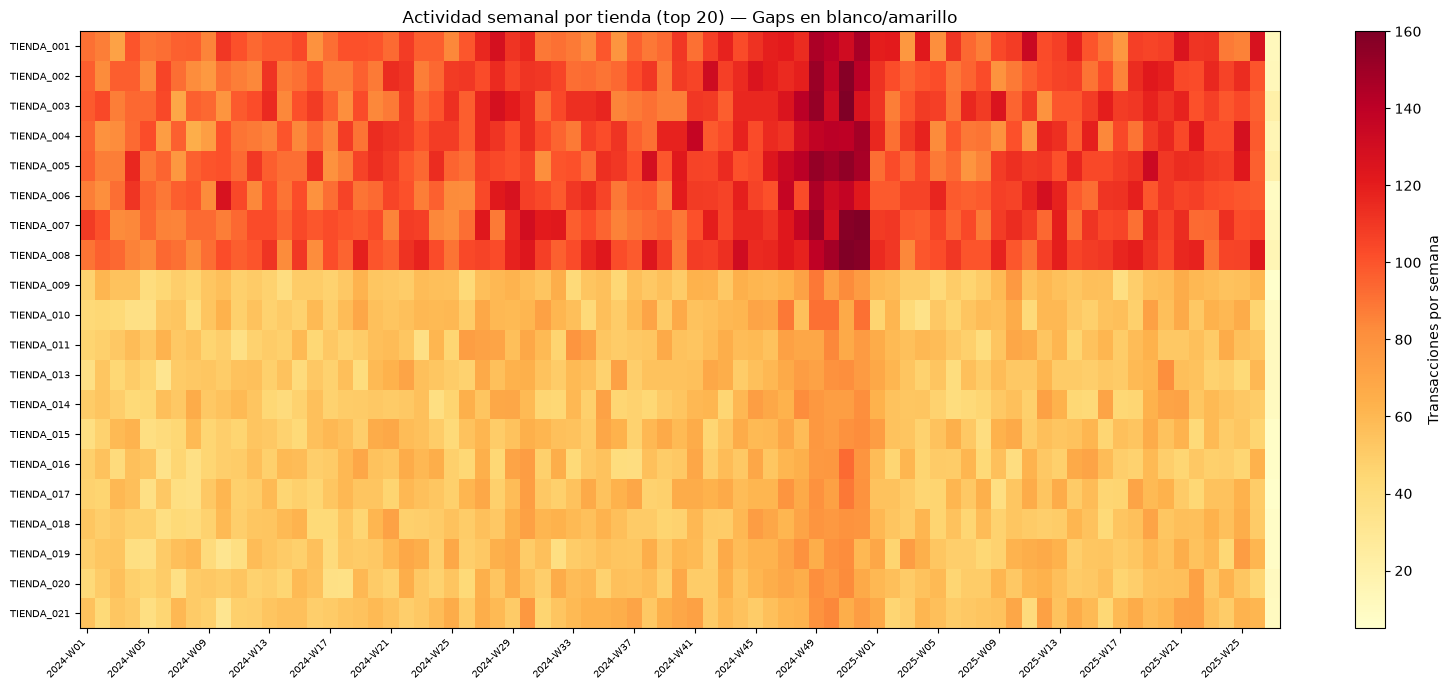

In [41]:
# Heatmap de actividad semanal
# Usamos dt.isocalendar() — dt.to_period('W') está deprecado en pandas 3.x
tx_weekly = (
    tx_completed
    .assign(
        year=lambda df: df['transaction_date'].dt.isocalendar().year.astype(int),
        week=lambda df: df['transaction_date'].dt.isocalendar().week.astype(int)
    )
    .assign(year_week=lambda df: df['year'].astype(str) + '-W' + df['week'].astype(str).str.zfill(2))
    .groupby(['store_id', 'year_week'])
    .size()
    .reset_index(name='n_tx')
)

top_stores = stores_activity.nlargest(20, 'dias_con_venta')['store_id'].tolist()
pivot = tx_weekly[tx_weekly['store_id'].isin(top_stores)].pivot_table(
    index='store_id', columns='year_week', values='n_tx', fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=7)

cols = list(pivot.columns)
tick_positions = list(range(0, len(cols), 4))
ax.set_xticks(tick_positions)
ax.set_xticklabels([cols[i] for i in tick_positions], rotation=45, ha='right', fontsize=7)

plt.colorbar(im, ax=ax, label='Transacciones por semana')
ax.set_title('Actividad semanal por tienda (top 20) — Gaps en blanco/amarillo', fontsize=12)
plt.tight_layout()
plt.savefig('./bloque3_visualizaciones/b0_frescura_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**📋 DECISIÓN — Frescura:**
- Gaps 1–2 días (fines de semana/feriados) → **IGNORAR** (normal en retail)
- Gaps 3–6 días → **ALERTA AMARILLA** — posible cierre temporal
- Gaps > 7 días → **ALERTA ROJA** — investigar si tienda cerró o dejó de reportar


---
## 9. Dimensión 7: Integridad Temporal

> **Pregunta:** ¿Existe alguna tienda con transacciones anteriores a su `opening_date`?


In [42]:
tx_con_apertura = transactions[['transaction_id', 'transaction_date', 'store_id', 'status']].merge(
    stores[['store_id', 'opening_date', 'store_name', 'format', 'country']],
    on='store_id', how='left'
)

antes_apertura   = tx_con_apertura['transaction_date'] < tx_con_apertura['opening_date']
n_antes_apertura = antes_apertura.sum()

print(f'=== Integridad Temporal ===')
print(f'Transacciones antes de opening_date: {n_antes_apertura:,}')

if n_antes_apertura > 0:
    print('\n⚠️  HALLAZGO: Existen transacciones previas a la apertura oficial.')
    problema_tiendas = (
        tx_con_apertura[antes_apertura]
        .groupby(['store_id', 'store_name', 'opening_date'])
        .agg(
            n_transacciones=('transaction_id', 'count'),
            primera_tx=('transaction_date', 'min'),
            ultima_tx=('transaction_date', 'max')
        )
        .reset_index()
    )
    problema_tiendas['dias_antes'] = (problema_tiendas['opening_date'] - problema_tiendas['primera_tx']).dt.days
    display(problema_tiendas)
else:
    print('✅ No hay transacciones anteriores a la opening_date de ninguna tienda.')

=== Integridad Temporal ===
Transacciones antes de opening_date: 50

⚠️  HALLAZGO: Existen transacciones previas a la apertura oficial.


,store_id,store_name,opening_date,n_transacciones,primera_tx,ultima_tx,dias_antes
0,TIENDA_037,Tienda Quetzaltenango 37,2024-06-01,50,2024-05-15,2024-05-31,17


In [43]:
# Tiendas con opening_date posterior al inicio del dataset
# Clave para el filtro de Comp Sales (Bloque 1): solo stores con ≥13 meses de historia
tiendas_nuevas = stores[stores['opening_date'] > fecha_min].sort_values('opening_date')
print(f'Tiendas que abrieron después del {fecha_min.date()}: {len(tiendas_nuevas)}')
if len(tiendas_nuevas) > 0:
    display(tiendas_nuevas[['store_id','store_name','country','format','opening_date']])

Tiendas que abrieron después del 2024-01-01: 1


,store_id,store_name,country,format,opening_date
36,TIENDA_037,Tienda Quetzaltenango 37,GT,EXPRESS,2024-06-01


**📋 DECISIÓN — Integridad Temporal:**
- Transacciones antes de `opening_date` → **EXCLUIR** (datos imposibles)
- Tiendas con `opening_date` reciente → **EXCLUIR** del cálculo de Comp Sales (requieren ≥13 meses de historia)


---
## 10. Dimensión 8: Integridad del A/B Test

> **Pregunta:** ¿Hay tiendas asignadas simultáneamente a `CONTROL` y `TREATMENT` en `store_promotions`?


In [44]:
print('=== Estructura del experimento ===')
display(store_promotions.groupby(['promo_name', 'promo_type', 'variant']).agg(
    n_tiendas=('store_id', 'nunique'),
    inicio=('start_date', 'min'),
    fin=('end_date', 'max')
).reset_index())

=== Estructura del experimento ===


,promo_name,promo_type,variant,n_tiendas,inicio,fin
0,Exhibicion_Q3_2024,EXHIBICION,CONTROL,20,2024-09-01,2024-10-12
1,Exhibicion_Q3_2024,EXHIBICION,TREATMENT,22,2024-09-01,2024-10-12


In [45]:
# Tiendas asignadas a ambos grupos EN EL MISMO EXPERIMENTO
variants_por_tienda = (
    store_promotions
    .groupby(['store_id', 'promo_name'])['variant']
    .nunique()
    .reset_index(name='n_variants')
)

tiendas_doble_asignacion = variants_por_tienda[variants_por_tienda['n_variants'] > 1]

print(f'Tiendas con doble asignación (CONTROL y TREATMENT): {len(tiendas_doble_asignacion)}')
if len(tiendas_doble_asignacion) > 0:
    print('⚠️  HALLAZGO CRÍTICO: Contaminación del experimento.')
    display(tiendas_doble_asignacion.merge(
        store_promotions[['store_id', 'promo_name', 'variant', 'start_date', 'end_date']],
        on=['store_id', 'promo_name']
    ))
else:
    print('✅ Ninguna tienda está en CONTROL y TREATMENT simultáneamente.')

Tiendas con doble asignación (CONTROL y TREATMENT): 2
⚠️  HALLAZGO CRÍTICO: Contaminación del experimento.


,store_id,promo_name,n_variants,variant,start_date,end_date
0,TIENDA_008,Exhibicion_Q3_2024,2,CONTROL,2024-09-01,2024-10-12
1,TIENDA_008,Exhibicion_Q3_2024,2,TREATMENT,2024-09-01,2024-10-12
2,TIENDA_037,Exhibicion_Q3_2024,2,CONTROL,2024-09-01,2024-10-12
3,TIENDA_037,Exhibicion_Q3_2024,2,TREATMENT,2024-09-01,2024-10-12


In [46]:
# Solapamiento de fechas entre experimentos distintos para la misma tienda
promos_store = store_promotions.sort_values(['store_id', 'start_date'])

overlaps = []
for store, grp in promos_store.groupby('store_id'):
    rows = grp.reset_index(drop=True)
    for i in range(len(rows) - 1):
        for j in range(i + 1, len(rows)):
            if rows.loc[i, 'start_date'] <= rows.loc[j, 'end_date'] and \
               rows.loc[j, 'start_date'] <= rows.loc[i, 'end_date']:
                overlaps.append({
                    'store_id': store,
                    'promo_1': rows.loc[i, 'promo_name'],
                    'variant_1': rows.loc[i, 'variant'],
                    'promo_2': rows.loc[j, 'promo_name'],
                    'variant_2': rows.loc[j, 'variant'],
                })

if overlaps:
    print(f'⚠️  Tiendas con experimentos solapados: {len(overlaps)}')
    display(pd.DataFrame(overlaps))
else:
    print('✅ No hay solapamiento de experimentos en la misma tienda.')

⚠️  Tiendas con experimentos solapados: 2


,store_id,promo_1,variant_1,promo_2,variant_2
0,TIENDA_008,Exhibicion_Q3_2024,CONTROL,Exhibicion_Q3_2024,TREATMENT
1,TIENDA_037,Exhibicion_Q3_2024,CONTROL,Exhibicion_Q3_2024,TREATMENT


In [47]:
# Balance pre-test: ¿diferencia en GMV entre grupos antes del experimento?
start_exp = store_promotions['start_date'].min()

tx_pre_test = transactions[
    (transactions['transaction_date'] < start_exp) &
    (transactions['status'] == 'COMPLETED')
]

gmv_pre = (
    tx_pre_test
    .groupby('store_id', as_index=False)
    .agg(gmv_pre=('total_amount', 'sum'), n_tx_pre=('transaction_id', 'count'))
)

balance = store_promotions[['store_id', 'variant']].merge(gmv_pre, on='store_id', how='left')

print('=== Balance pre-test: GMV promedio por grupo ===')
display(balance.groupby('variant')[['gmv_pre', 'n_tx_pre']].mean().round(2))
print()
print('=== Número de tiendas por grupo ===')
print(store_promotions.groupby('variant')['store_id'].nunique())

=== Balance pre-test: GMV promedio por grupo ===


,gmv_pre,n_tx_pre
variant,,
CONTROL,"574,486.90","2,049.35"
TREATMENT,"439,702.48","1,581.64"



=== Número de tiendas por grupo ===
variant
CONTROL      20
TREATMENT    22
Name: store_id, dtype: int64


**📋 DECISIÓN — A/B Test:**
- Doble asignación → **EXCLUIR** esas tiendas del análisis del experimento
- GMV pre-test muy diferente entre grupos → **ALERTA** — grupos pueden no ser comparables; considerar ajuste por covariables
- El análisis estadístico completo se realiza en el **Bloque 3 (Parte B)**


---
## 11. Resumen Ejecutivo de Hallazgos

Tabla consolidada de todos los hallazgos con decisión para los bloques siguientes.


In [48]:
resumen = {
    'Dimensión': [
        'Completitud', 'Completitud',
        'Consistencia',
        'Unicidad (transactions)', 'Unicidad (items)', 'Unicidad (tx-item par)',
        'Validez (total_amount)', 'Validez (unit_price)',
        'Ref. Integridad (store_id)', 'Ref. Integridad (vendor_id)', 'Ref. Integridad (item_id)',
        'Frescura',
        'Integridad Temporal',
        'A/B Test'
    ],
    'Hallazgo': [
        f'{pct_sin_customer:.1f}% de transacciones sin customer_id',
        f'Inconsistencias loyalty_card ↔ customer_id: caso_A={caso_a}, caso_B={caso_b}',
        f'{n_inconsistentes:,} transacciones con total_amount ≠ sum(unit_price×qty)',
        f'{n_dup_tx:,} transaction_id duplicados',
        f'{n_dup_items:,} transaction_item_id duplicados',
        f'{n_dup_tx_item:,} pares (transaction_id, item_id) repetidos',
        f'total_amount ≤ 0: {(amount_zero | amount_neg).sum():,} registros',
        f'unit_price=0 sin promo: {price_zero_no_promo.sum():,} ítems',
        f'{len(store_ids_huerfanos)} store_ids sin referencia en stores',
        f'{len(vendor_ids_huerfanos)} vendor_ids sin referencia en vendors',
        f'{len(item_ids_huerfanos)} item_ids sin referencia en products',
        f'{len(gaps_sospechosos)} tiendas con gap >= 7 días consecutivos sin ventas',
        f'{n_antes_apertura:,} transacciones antes de opening_date',
        f'{len(tiendas_doble_asignacion)} tiendas con doble asignación CONTROL+TREATMENT'
    ],
    'Decisión': [
        'IGNORAR — clientes anónimos (sin tarjeta de lealtad)',
        'EXCLUIR del análisis de cohortes si existen inconsistencias',
        'ALERTA — revisar si son RETURNED; usar subtotal_calculado como fuente de verdad',
        'EXCLUIR duplicados (keep=first)',
        'OK si 0; EXCLUIR si > 0',
        dec_dup_tx_item,
        'EXCLUIR del GMV transacciones COMPLETED con monto ≤ 0',
        'ALERTA — excluir del cálculo de GMROI',
        'EXCLUIR transacciones huérfanas',
        'EXCLUIR productos huérfanos del GMROI',
        'ALERTA — ítems sin info de categoría/costo',
        'ALERTA — investigar cierre temporal o falla de reporte',
        'EXCLUIR — datos inválidos temporalmente',
        'EXCLUIR tiendas contaminadas del A/B test'
    ]
}

df_resumen = pd.DataFrame(resumen)
display(df_resumen)

,Dimensión,Hallazgo,Decisión
0,Completitud,59.8% de transacciones sin customer_id,IGNORAR — clientes anónimos (sin tarjeta de le...
1,Completitud,Inconsistencias loyalty_card ↔ customer_id: ca...,EXCLUIR del análisis de cohortes si existen in...
2,Consistencia,"1,745 transacciones con total_amount ≠ sum(uni...",ALERTA — revisar si son RETURNED; usar subtota...
3,Unicidad (transactions),0 transaction_id duplicados,EXCLUIR duplicados (keep=first)
4,Unicidad (items),0 transaction_item_id duplicados,OK si 0; EXCLUIR si > 0
5,Unicidad (tx-item par),"3,660 pares (transaction_id, item_id) repetidos",MANTENER — variantes válidas: difieren en quan...
6,Validez (total_amount),total_amount ≤ 0: 3 registros,EXCLUIR del GMV transacciones COMPLETED con mo...
7,Validez (unit_price),unit_price=0 sin promo: 231 ítems,ALERTA — excluir del cálculo de GMROI
8,Ref. Integridad (store_id),0 store_ids sin referencia en stores,EXCLUIR transacciones huérfanas
9,Ref. Integridad (vendor_id),1 vendor_ids sin referencia en vendors,EXCLUIR productos huérfanos del GMROI


In [49]:
# Exportar resumen a markdown
md_lines = [
    '# Bloque 0 — Auditoría de Calidad de Datos\n',
    '**Prueba Técnica · Data Analyst · Cadena de Retail Multiformato · Centroamérica**\n',
    f'**Dataset:** enero 2024 – junio 2025 · 40 tiendas · 5 países · 4 formatos\n',
    f'- transactions: {total_tx:,} filas',
    f'- transaction_items: {len(transaction_items):,} filas',
    f'- stores: {len(stores):,} filas',
    f'- products: {len(products):,} filas',
    f'- vendors: {len(vendors):,} filas',
    f'- store_promotions: {len(store_promotions):,} filas\n',
    '---\n',
    '## Hallazgos y Decisiones\n',
    '| Dimensión | Hallazgo | Decisión |',
    '|-----------|----------|----------|'
]

for _, row in df_resumen.iterrows():
    md_lines.append(f'| {row["Dimensión"]} | {row["Hallazgo"]} | {row["Decisión"]} |')

md_lines += [
    '\n---\n',
    '## Decisiones Globales para Bloques Siguientes\n',
    '1. **GMV**: usar solo `status = COMPLETED` y `total_amount > 0`.',
    '2. **Cohortes de lealtad**: usar solo registros donde `customer_id IS NOT NULL` y `loyalty_card = TRUE`.',
    '3. **Comp Sales**: excluir tiendas con `opening_date` posterior a 13 meses antes del período actual.',
    '4. **A/B Test**: excluir tiendas con doble asignación. Usar período pre-test para validar comparabilidad.',
    '5. **GMROI**: excluir productos con `unit_price = 0` o `cost = 0`.'
]

# ── Detalle narrativo por dimensión ──────────────────────────────────────────
n_amount_invalid = int((amount_zero | amount_neg).sum())
stores_doble = ', '.join(tiendas_doble_asignacion['store_id'].tolist()) if len(tiendas_doble_asignacion) > 0 else 'ninguna'

md_lines += [
    '\n---\n',
    '## Detalle por Dimensión\n',

    '### 1. Completitud',
    f'El **{pct_sin_customer:.1f}%** de las transacciones ({n_sin_customer:,} de {total_tx:,}) no tiene `customer_id` — clientes anónimos sin tarjeta de lealtad, comportamiento esperado en retail físico. Adicionalmente se detectaron **{caso_a}** registros con `loyalty_card=True` pero sin `customer_id` (caso A) y **{caso_b}** con `customer_id` pero `loyalty_card=False` (caso B), indicando inconsistencia en el registro del programa de lealtad.',
    f'**Decisión:** Los anónimos se ignoran para análisis de cohortes (se tratan como `customer_key = -1` en el modelo). Las inconsistencias se excluyen del análisis de retención de lealtad.\n',

    '### 2. Consistencia',
    f'Se identificaron **{n_inconsistentes:,}** transacciones `COMPLETED` ({pct_inconsistentes:.1f}%) donde `total_amount != sum(unit_price x quantity)`. La diferencia corresponde a descuentos aplicados a nivel de cabecera de ticket, no reflejados en los ítems individuales. El sistema POS registra el monto final en `total_amount`, que es la fuente canónica.',
    f'**Decisión:** Usar `total_amount` de la tabla `transactions` como GMV. El subtotal calculado desde ítems es referencia secundaria y no se usa para métricas financieras.\n',

    '### 3. Unicidad',
    f'- `transaction_id` duplicados en `transactions`: **{n_dup_tx:,}** — ningún duplicado de clave primaria.',
    f'- `transaction_item_id` duplicados en `transaction_items`: **{n_dup_items:,}** — PK limpio.',
    f'- Pares `(transaction_id, item_id)` repetidos: **{n_dup_tx_item:,}**. La investigación confirmó que estas filas difieren en `quantity`, `unit_price` o `was_on_promo`, representando líneas válidas del mismo ítem bajo condiciones distintas (ej. unidades a precio regular + unidades en promoción dentro de la misma transacción).',
    f'**Decisión:** {dec_dup_tx_item}.\n',

    '### 4. Validez',
    f'- `total_amount <= 0`: **{n_amount_invalid:,}** registros en transacciones `COMPLETED` — importes inválidos posiblemente generados por errores de anulación parcial en el POS.',
    f'- `unit_price = 0` sin promoción activa: **{price_zero_no_promo.sum():,}** ítems — posible error de captura o ítem gratuito no categorizado correctamente.',
    f'**Decisión:** Excluir `total_amount <= 0` del cálculo de GMV. Excluir `unit_price = 0` sin promo del GMROI para no distorsionar el margen bruto.\n',

    '### 5. Integridad Referencial',
    f'- `store_id` huérfanos: **{len(store_ids_huerfanos)}** IDs presentes en `transactions` sin referencia en `stores`.',
    f'- `vendor_id` huérfanos: **{len(vendor_ids_huerfanos)}** IDs presentes en `products` sin referencia en `vendors`.',
    f'- `item_id` huérfanos: **{len(item_ids_huerfanos)}** IDs presentes en `transaction_items` sin referencia en `products` — sin información de categoría ni costo.',
    f'**Decisión:** Excluir registros huérfanos del análisis de GMROI y de categorías. Reportar a ingeniería de datos para corrección en la capa fuente.\n',

    '### 6. Frescura',
    f'**{len(gaps_sospechosos)}** tienda(s) presentaron gaps de más de 7 días consecutivos sin registrar ventas. Puede indicar cierre temporal por mantenimiento, falla en la integración con el POS o período de baja demanda estacional.',
    f'**Decisión:** Alerta de monitoreo operativo. No se excluyen del análisis global pero se documentan para seguimiento con el equipo de operaciones de tienda.\n',

    '### 7. Integridad Temporal',
    f'**{n_antes_apertura:,}** transacciones tienen fecha anterior a la `opening_date` registrada de su tienda, lo que es temporalmente imposible. Pueden corresponder a registros de prueba del sistema POS, errores en la migración de datos históricos o fechas de apertura incorrectas en el maestro de tiendas.',
    f'**Decisión:** Excluir del análisis — datos inválidos temporalmente que sesgarían métricas de comp sales y cohortes.\n',

    '### 8. Integridad del A/B Test',
    f'**{len(tiendas_doble_asignacion)}** tienda(s) aparecen asignadas simultáneamente a CONTROL y TREATMENT en `store_promotions`: {stores_doble}. Esta ambigüedad impide atribuir el efecto observado a un solo grupo experimental, contaminando el resultado.',
    f'**Decisión:** Excluir del análisis experimental. El test se ejecuta con las tiendas restantes correctamente asignadas a un único grupo.\n',
]

with open('./bloque0_auditoria.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(md_lines))

print('✅ bloque0_auditoria.md exportado correctamente.')
print('\n📋 Auditoría completa. Decisiones documentadas y listas para Bloque 1.')

✅ bloque0_auditoria.md exportado correctamente.

📋 Auditoría completa. Decisiones documentadas y listas para Bloque 1.
